# Visualization of geodesic ray transforms

In [ ]:
from warnings import filterwarnings

import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
from skimage.io import imread
from skimage.transform import radon

from intgeom.geod import Gammas, solve_geod
from intgeom.plot import (
    PlotParams,
    plot_c,
    plot_detector,
    plot_geod,
    plot_init,
    plot_palette,
    plot_ph,
    plot_pr,
    plot_sources,
)
from intgeom.ray import Coords, project, sources

## Configuration

Phantom as an image file.

In [ ]:
phantom_path = "data/banana_lowres.jpg"

Visualize the phantom.

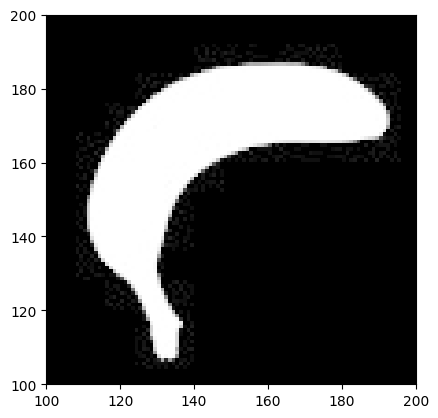

In [ ]:
ph = imread(phantom_path, as_gray=True)

coords = Coords(Nph=ph.shape[0])
plot_ph(coords, ph)

Wave speed as a symbolic expression.

In [ ]:
from sympy.abc import x, y

c_sym = 1 - 0.5 * sp.exp(-4 * (x**2 + y**2))

Visualize the wave speed.

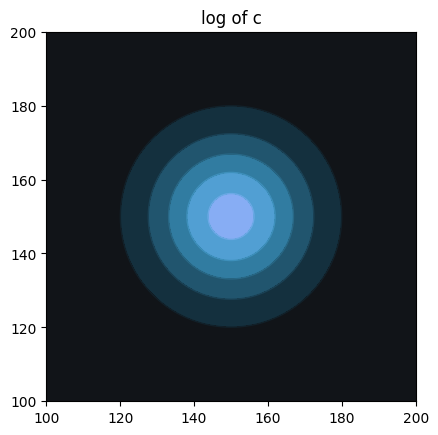

In [ ]:
plot_c(coords, c_sym)
plt.gca().set_title("log of c")
plt.gca().set_facecolor("black")
n = coords.Nph
plt.gca().set_xlim(n, 2 * n)
plt.gca().set_ylim(n, 2 * n)
plt.gca().set_aspect("equal")

Visualize the color palette. New colors can be injected into `palette`.

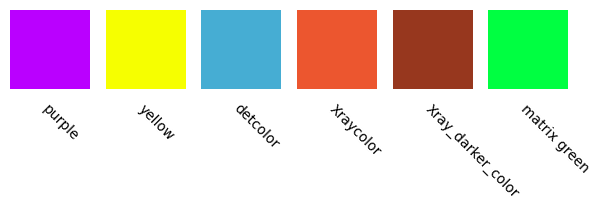

In [ ]:
plot_palette()

Default parameters for plotting. Any number of default values can be overridden when instantiating `PlotParams` (without touching the defaults). 

In [ ]:
pp = PlotParams()

## Canvas coordinates vs computational coordinates

In computations, we use such coordinates that the phantom (which is assumed to be a square) is in $[-1,1]^2$ and the canvas is $[-3,3]^2$. When evaluating the phantom in computational coordinates, we use simple interpolation. This is good enough for our visualization purposes.

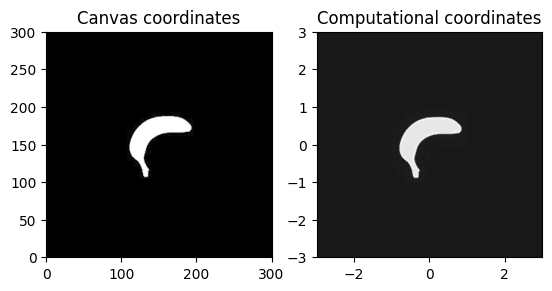

In [ ]:
fig, axes = plt.subplots(1, 2)

plt.sca(axes.flat[0])
plt.gca().set_title("Canvas coordinates")
plot_init(coords)
plot_ph(coords, ph)

plt.sca(axes.flat[1])
plt.gca().set_title("Computational coordinates")
xs = np.linspace(-3, 3, 3 * coords.Nph)
Xs, Ys = np.meshgrid(xs, xs)
ph_interp = coords.ph_from_canvas(ph)
Zs = ph_interp((Xs, Ys))
plt.contourf(Xs, Ys, Zs, 100, cmap="gray")
plt.gca().set_aspect("equal")

## Source geometry

The sources are on the line segment $\{-1\} \times [-1,1]$ emitting to the direction $(1,0)$. This source geometry can be rotated around the origin. 

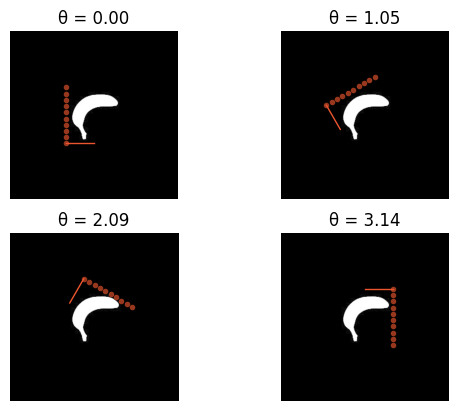

In [ ]:
fig, axes = plt.subplots(2, 2)
ths = np.linspace(0, np.pi, 4)

for ax, th in zip(axes.flat, ths):
    plt.sca(ax)
    plot_init(coords)
    plot_ph(coords, ph)

    src_pts, src_dir = sources(th=th)

    plot_sources(coords, src_pts)

    # Source direction
    p0 = src_pts[:, 0]
    plt.plot(
        *coords.to_canvas(np.stack([p0, p0 + src_dir]).T),
        "-",
        color=pp.palette["Xraycolor"],
        linewidth=1,
    )

    plt.gca().set_title(f"θ = {th:.2f}")
    plt.gca().axis("off")

## Visualization of projections

The projection is parametrized by source, not by receiver, since the rays don't align nicely on the opposite side in the non-Euclidean case. We visualize the projections on the source side as this is less confusing.

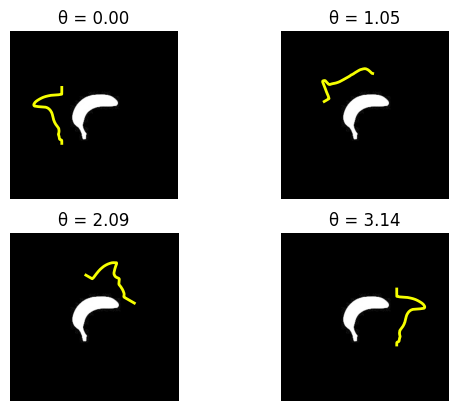

In [ ]:
fig, axes = plt.subplots(2, 2)
ths = np.linspace(0, np.pi, 4)
ths_d = -90 + np.degrees(ths)

filterwarnings("ignore", message="Radon transform:.*")
sinogram = radon(np.flipud(ph), theta=ths_d).T
MAXsino = np.max(sinogram)

for ax, th, pr in zip(axes.flat, ths, sinogram):
    plt.sca(ax)
    plot_init(coords)
    plot_ph(coords, ph)
    plot_pr(coords, pr, MAXsino, th)
    plt.gca().set_title(f"θ = {th:.2f}")
    plt.gca().axis("off")

## Geodesics

Visualization of geodesics.

The glow effect is adapted from [mplcyberpunk](https://github.com/dhaitz/mplcyberpunk) (MIT License).


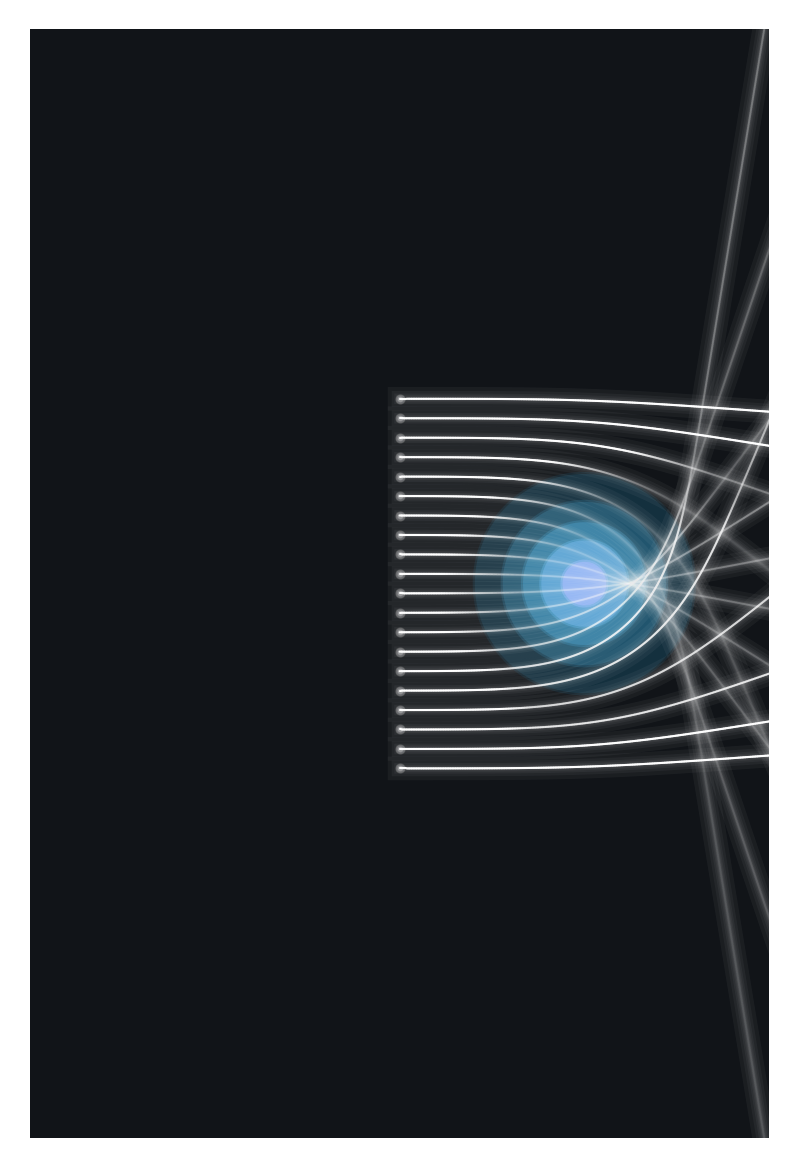

In [ ]:
from matplotlib.collections import LineCollection
from scipy.integrate import cumulative_simpson

ph_fine = imread(phantom_path, as_gray=True)

coords_fine = Coords(Nph=ph_fine.shape[0])

attn_coeff = 0.013
attn_max = 0
n_glow = 6
glow_alpha = 0.25
glow_growth = 1.5

glow_marker_alpha = 0.4
glow_marker_growth = 1.2


Gammas_c = Gammas(c_sym)
pp_fine = PlotParams(ccontourwidth=0.5, raywidth=0.5)

plt.figure(dpi=300)

plot_c(coords_fine, c_sym, pp=pp_fine)

src_pts, src_dir = sources(Nrays=20)
for src_pt in src_pts.T:
    sol = solve_geod(src_pt, src_dir, Gammas_c)
    ts = np.linspace(0, sol.t[-1], 600)
    gamma = sol.sol(ts)[0:2, :]

    def f(t):
        u = sol.sol(t)
        return float(ph_interp((u[0], u[1])))

    fts = np.array([f(t) for t in ts])
    Fts = cumulative_simpson(fts, x=ts)
    attns = np.clip(
        (1 - attn_max) * np.exp(-attn_coeff * Fts) + attn_max, 0, 1
    )

    pts = coords.to_canvas(gamma).T.reshape(-1, 1, 2)
    segments = np.concatenate([pts[:-1], pts[1:]], axis=1)
    colors = np.ones((len(segments), 4))

    colors[:, 3] = attns
    plt.gca().add_collection(
        LineCollection(
            segments,
            colors=colors,
            linewidth=pp_fine.raywidth,
            capstyle="round",
        )
    )

    alpha = glow_alpha / n_glow
    for n in range(1, n_glow + 1):
        plt.plot(
            *coords.to_canvas(gamma),
            "-",
            color="white",
            linewidth=pp_fine.raywidth * (glow_growth**n),
            alpha=alpha,
        )

alpha = glow_marker_alpha / n_glow
for n in range(1, n_glow):
    plt.scatter(
        *coords.to_canvas(src_pts),
        s=(glow_marker_growth**n),
        c="white",
        alpha=alpha,
    )

plt.gca().set_xlim(0, 2 * coords_fine.Nph)
plt.gca().set_ylim(0, 3 * coords_fine.Nph)
plt.gca().axis("off")
plt.gca().set_aspect("equal")

## Exit times

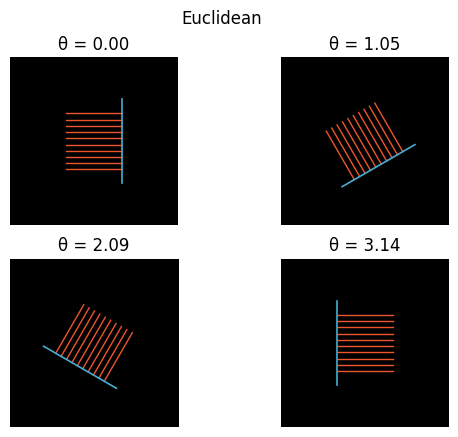

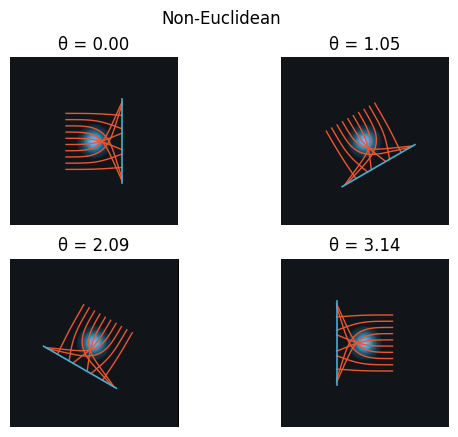

In [ ]:
c_syms = [1, c_sym]
titles = ["Euclidean", "Non-Euclidean"]

for c, title in zip(c_syms, titles):
    fig, axes = plt.subplots(2, 2)
    fig.suptitle(title)
    ths = np.linspace(0, np.pi, 4)

    Gammas_c = Gammas(c, [x, y])

    for ax, th in zip(axes.flat, ths):
        plt.sca(ax)
        plot_init(coords)
        plot_c(coords, c, symbols=[x, y])

        src_pts, src_dir = sources(th=th)
        for src_pt in src_pts.T:
            plot_geod(
                coords, solve_geod(src_pt, src_dir, Gammas_c), th=th
            )

        plot_detector(coords, th=th)
        plt.gca().set_title(f"θ = {th:.2f}")
        plt.gca().axis("off")

## Projections

Compare with `radon` (after normalization) in the case of Euclidean geometry.

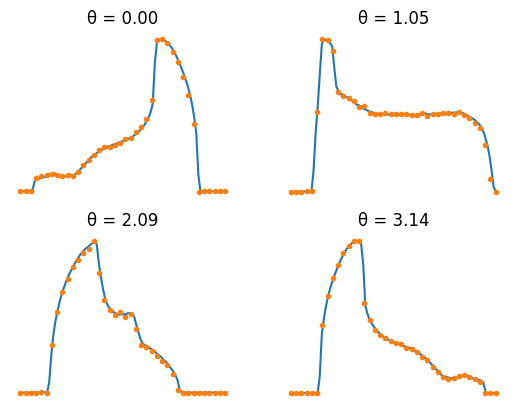

In [ ]:
Gammas_c = Gammas(1, [x, y])
Nrays = 40

fig, axes = plt.subplots(2, 2)
ths = np.linspace(0, np.pi, 4)

xs_radon = np.linspace(-1, 1, coords.Nph)
xs_project = np.linspace(-1, 1, Nrays)

for ax, th in zip(axes.flat, ths):
    plt.sca(ax)
    th_d = -90 + np.degrees(th)
    pr = radon(np.flipud(ph), theta=[th_d])
    pr = pr / np.max(pr)
    plt.plot(xs_radon, pr)

    pr = project(ph, Gammas_c, Nrays=Nrays, th=th)
    pr = pr / np.max(pr)
    plt.plot(xs_project, pr, ".")

    plt.gca().set_title(f"θ = {th:.2f}")
    plt.gca().axis("off")

## Interpolating between Euclidean geometry and a strong lens

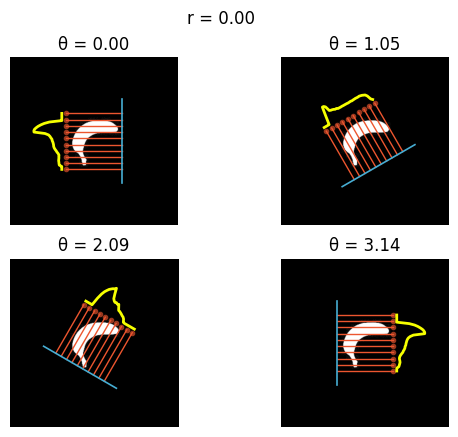

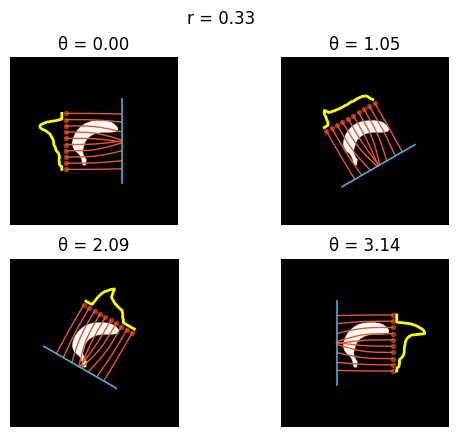

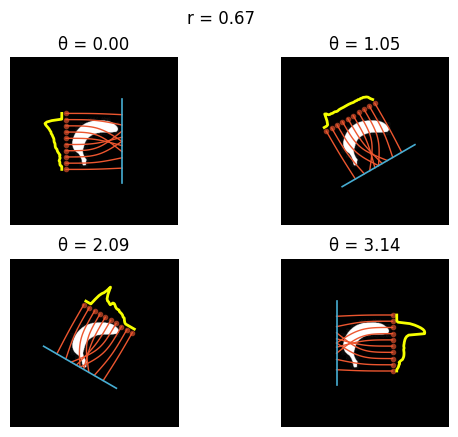

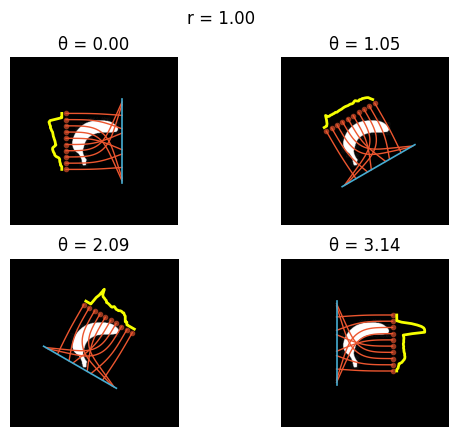

In [ ]:
rs = np.linspace(0, 1, 4)
Nrays = 40

for r in rs:
    c = r * c_sym + (1 - r)
    Gammas_c = Gammas(c, [x, y])

    fig, axes = plt.subplots(2, 2)
    fig.suptitle(f"r = {r:.2f}")
    ths = np.linspace(0, np.pi, 4)

    prs = np.zeros((len(rs), Nrays))
    for i in range(len(ths)):
        prs[i, :] = project(ph, Gammas_c, Nrays=Nrays, th=ths[i])
    prs_max = np.max(prs)

    for i in range(len(ths)):
        plt.sca(axes.flat[i])
        th = ths[i]
        pr = prs[i, :]

        plot_init(coords)
        plot_ph(coords, ph)

        src_pts, src_dir = sources(th=th)
        plot_sources(coords, src_pts)

        for src_pt in src_pts.T:
            plot_geod(
                coords, solve_geod(src_pt, src_dir, Gammas_c), th=th
            )

        plot_pr(coords, pr, prs_max, th=th)
        plot_detector(coords, th=th)

        plt.gca().set_title(f"θ = {th:.2f}")
        plt.gca().axis("off")